In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
sns.set_style('whitegrid')
sns.set_palette("Set2")

%matplotlib inline

# Leer los datos

In [6]:
df_fe = pd.read_csv("../../data/respuestas_fede.csv")
print(df_fe.shape)

#globales
marmol = df_fe.loc[df_fe["escuela"] == "Colegio Modelo Mármol"]
mantovani = df_fe.loc[df_fe["escuela"] == "Escuela Nueva Juan Mantovani"]
cant_total = len(df_fe)
cant_marmol = len(marmol)
cant_mantovani = len(mantovani)
# genero
cant_marmol_masc = len(marmol[marmol['genero']=="Masculino"])
cant_marmol_fem = len(marmol[marmol['genero']=="Femenino"])
cant_mantovani_masc = len(mantovani[mantovani['genero']=="Masculino"])
cant_mantovani_fem = len(mantovani[mantovani['genero']=="Femenino"])
# grados
cant_marmol_quinto = len(marmol[marmol['grado']=="Quinto"])
cant_marmol_sexto = len(marmol[marmol['grado']=="Sexto"])
cant_mantovani_cuarto = len(mantovani[mantovani['grado']=="Cuarto"])
cant_mantovani_quinto = len(mantovani[mantovani['grado']=="Quinto"])
cant_mantovani_sexto = len(mantovani[mantovani['grado']=="Sexto"])

(369, 22)


## ¿Dónde se almacenan los videos que están en YouTube? 

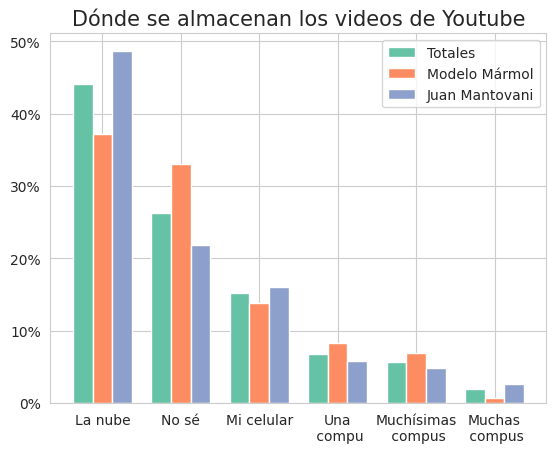

In [21]:
# ¿Dónde se almacenan los videos que están en YouTube? 
data_total = df_fe["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde se almacenan los videos de Youtube", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('donde_youtube.png')

* En ambos vemos las respuestas la nube y nose como las mas elegidas
* Menos de un 10% elige la opción sin misconception, si sumamos no sé llegamos a un 40% sin misc. en el Modelo Mármol y un 30% en el Mantovani. -> Este analisis debería estar a parte en otros gráficos creo.

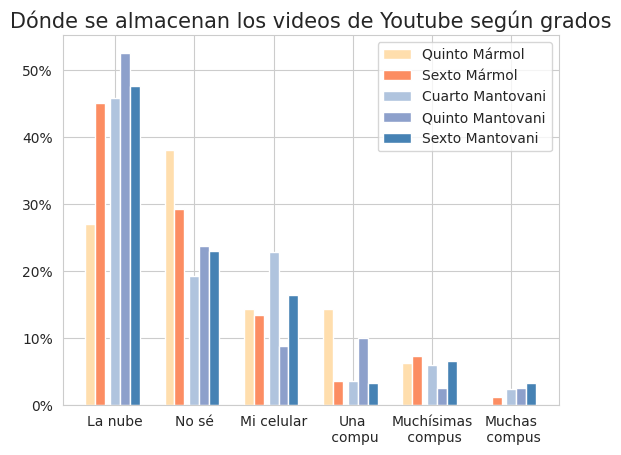

In [28]:
# ¿Dónde se almacenan los videos que están en YouTube? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                        index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

result = result.reindex(["La nube", 
                         "No sé",
                         "Mi celular", 
                         "Una\n compu",
                         "Muchísimas\n compus",
                         "Muchas\n compus"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde se almacenan los videos de Youtube según grados", fontsize=15)
plt.xticks([x + 2.5*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('donde_youtube_grados.png')


* Modelo Mármol: La nube es un 10% mas elegida de 5to a 6to. No sé y una Compu un 10% menos elegida de 4to a 5to.
* Mantovani: Mi celular varía entre 4to a 6to.


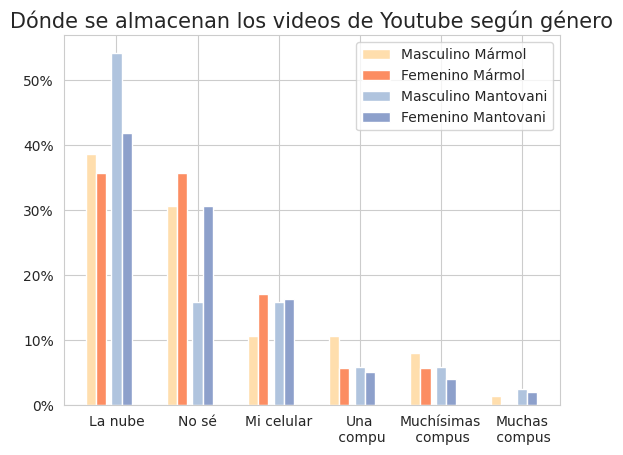

In [29]:
# ¿Dónde se almacenan los videos que están en YouTube? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["donde_youtube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"En la nube": "La nube",
                              "En mi celular": "Mi celular",
                              "En una computadora": "Una\n compu",
                              "En muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "En muchas computadoras (tantas que podrían llenar una casa)": "Muchas\n compus"}).fillna(0)

result = result.reindex(["La nube", 
                         "No sé",
                         "Mi celular", 
                         "Una\n compu",
                         "Muchísimas\n compus",
                         "Muchas\n compus"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Dónde se almacenan los videos de Youtube según género", fontsize=15)
plt.xticks([x + 2.5*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('donde_youtube_genero.png')

* Mármol: No hay diferencias notorias.
* Mantovani: un 10% más de los varones eligen la opción de La nube. Un 15 % más de las mujeres eligen No se.

# ¿Quién tiene acceso a las fotos que tengo guardadas en mi celular?

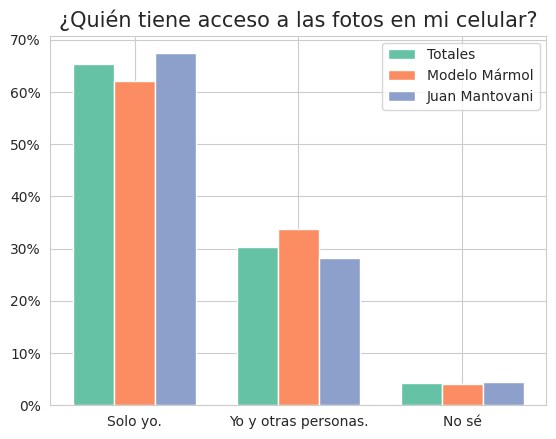

In [31]:
# Quien tiene acceso a las fotos en mi celular
data_total = df_fe["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"})

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Quién tiene acceso a las fotos en mi celular?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('quien_acceso_celular.png')

* Solo yo es un 5% más elegida en el Mantovani.
* Yo y otras personas un 5% más en el Mármol.

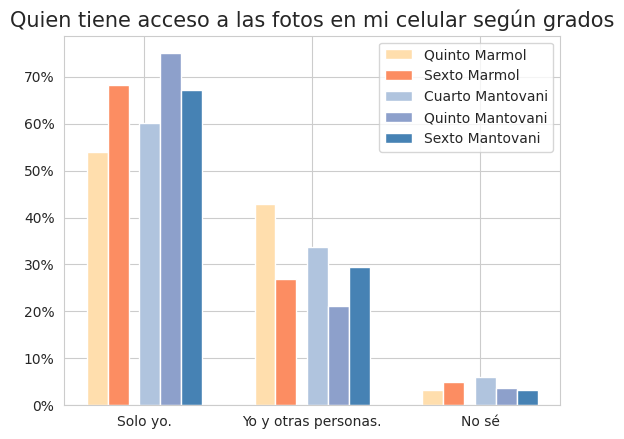

In [32]:
# Quien tiene acceso a las fotos en mi celular - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Marmol',
                                1:'Sexto Marmol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'})

bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Marmol']    , width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br2, result['Sexto Marmol']     , width=bar_width, label = 'Sexto Marmol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Quien tiene acceso a las fotos en mi celular según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('quien_acceso_celular_grados.png')

* Mármol: Solo yo un 15% más seleccionado de 5to a 6to. Yo y otras peronas un 15% menos seleccionado de 5to a 6to.
* Mantovani: Las variaciones son iguales pero en menor porcentaje para el Mantovani. Aumentan solo yo al crecer y cecrementan yo y otras personas.

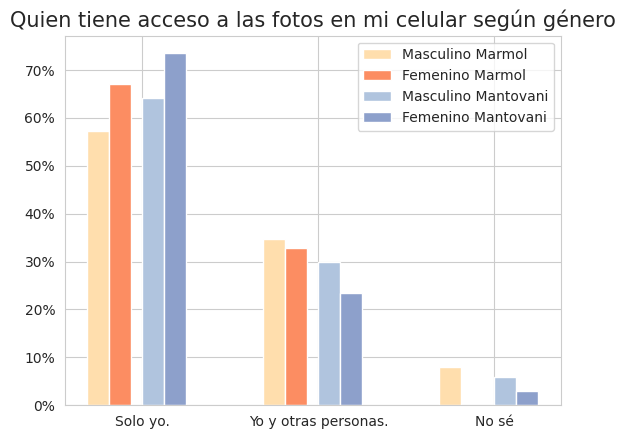

In [33]:
# Quien tiene acceso a las fotos en mi celular - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["quien_acceso_celular"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"})

bar_width = 0.25

br1 = [1, 3, 5]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"],     width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"],      width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Quien tiene acceso a las fotos en mi celular según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('quien_acceso_celular_genero.png')

En ambos colegios Solo yo es un 10% más elegido por las chicas y yo y otras peronas es un 5% menos elegido por las chicas

# Cuando le mando a una amiga una foto por WhatsApp..

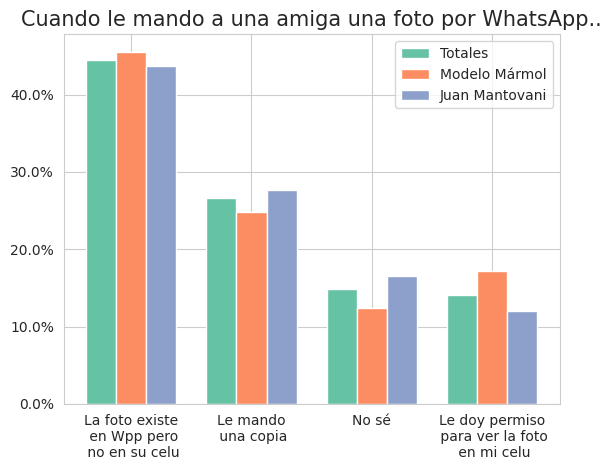

In [37]:
# Cuando le mando a una amiga una foto por WhatsApp..
data_total = df_fe["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Cuando le mando a una amiga una foto por WhatsApp..", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('amiga_wpp.png')

* En el Mármol contestan No sé un 5% menos que en el Mantovani.
* Mármol contesta 5% más "Le doy permiso" que el Mantovani.

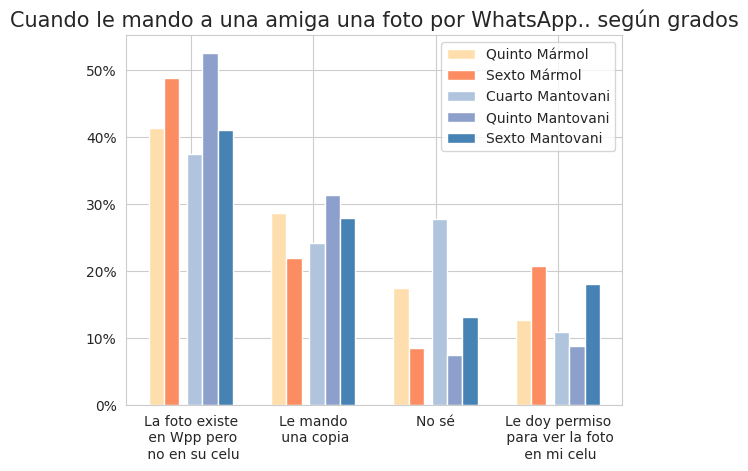

In [40]:
# Cuando le mando a una amiga una foto por WhatsApp.. - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

result = result.reindex(["La foto existe\n en Wpp pero\n no en su celu",
                         "Le mando\n una copia",
                         "No sé",
                         "Le doy permiso\n para ver la foto\n en mi celu"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Cuando le mando a una amiga una foto por WhatsApp.. según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('amiga_wpp_grados.png')

* No se aprecia un patrón que se repita en ambos colegios porque 5to del Mantovani no está entre los datos de 4to y 6to. 
* La foto existe en wpp es más elegida en alumnes más grandes en el Mármol. Tambien en el Mantovani de 4to a 6to y de 4to a 5to pero cambia en un 10% el porcentaje de 5to a 6to.
* Le mando una copia se mantiene similar en ambos colegios.
* No se es un 10% menos elegida en chicos más grandes en el Modelo y un 20% menos en el Mantovani entre los de 5to y 6to respecto a los de 4to.
* Le doy permiso es un 10% más elegida en chicos de 6to para ambos colegios

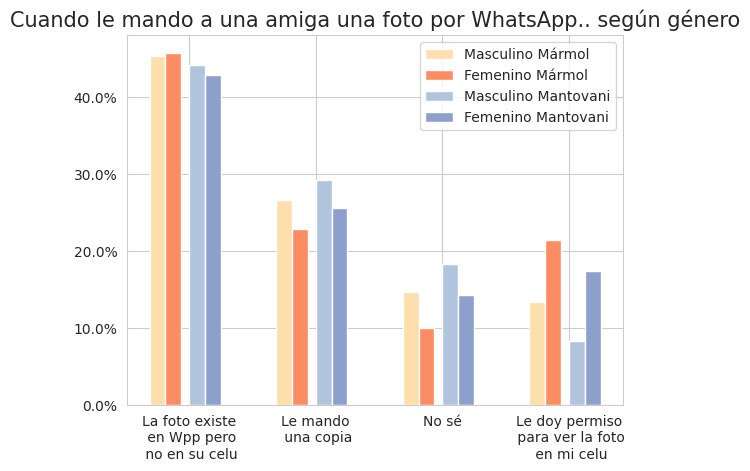

In [42]:
# Cuando le mando a una amiga una foto por WhatsApp.. - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["amiga_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"La foto ahora existe en WhatsApp y mi amiga la puede ver cuando mira nuestro chat, pero no la tiene en su celular":"La foto existe\n en Wpp pero\n no en su celu",
                              "Le mando una copia de mi foto.": "Le mando\n una copia",
                              "Le doy permiso para ver la foto que tengo guardada en mi celular.": "Le doy permiso\n para ver la foto\n en mi celu"}).fillna(0)

result = result.reindex(["La foto existe\n en Wpp pero\n no en su celu",
                         "Le mando\n una copia",
                         "No sé",
                         "Le doy permiso\n para ver la foto\n en mi celu"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Cuando le mando a una amiga una foto por WhatsApp.. según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('amiga_wpp_genero.png')

* Le doy permiso es un 10% más elegida en las chicas en ambos colegios.

# Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer?

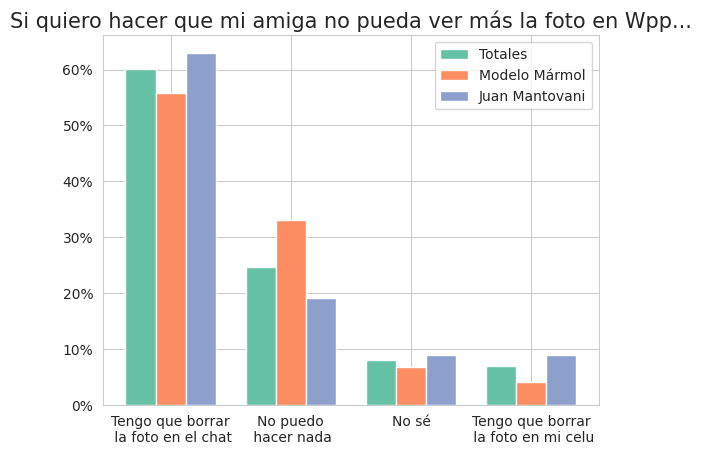

In [8]:
# Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer?
data_total = df_fe["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

result = result.reindex(["Tengo que borrar\n la foto en el chat",
          "No puedo\n hacer nada", 
          "No sé", 
          "Tengo que borrar\n la foto en mi celu"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si quiero hacer que mi amiga no pueda ver más la foto en Wpp...", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('amiga_no_ver_foto.png')

* En Mármol se elige un 10% más la respuesta "No puedo hacer nada"

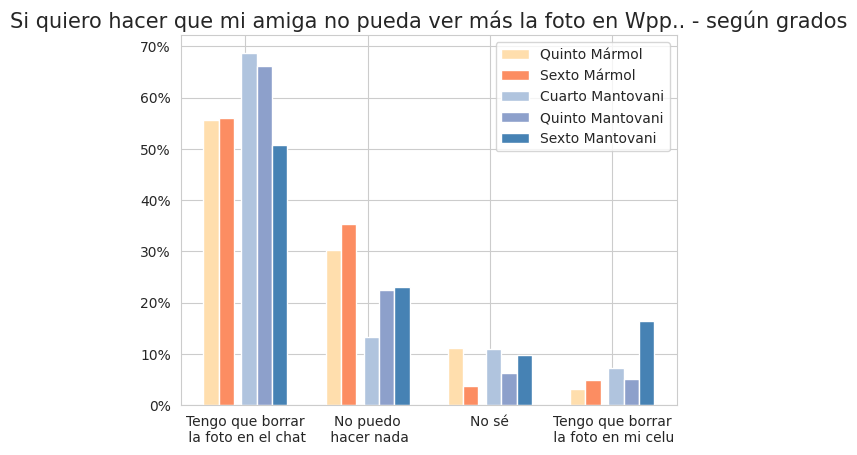

In [12]:
# Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

result = result.reindex(["Tengo que borrar\n la foto en el chat",
          "No puedo\n hacer nada", 
          "No sé", 
          "Tengo que borrar\n la foto en mi celu"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si quiero hacer que mi amiga no pueda ver más la foto en Wpp.. - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('amiga_no_ver_foto_grados.png')

* No hay cambios en el Modelo Mármol según grado
* En el Mantovani, de 4to a 6to baja la opcion "Tengo que borrar la foto" un 20% , sube un 10% no puedo hacer nada y sube un 10% "tengo que borrar la foto"

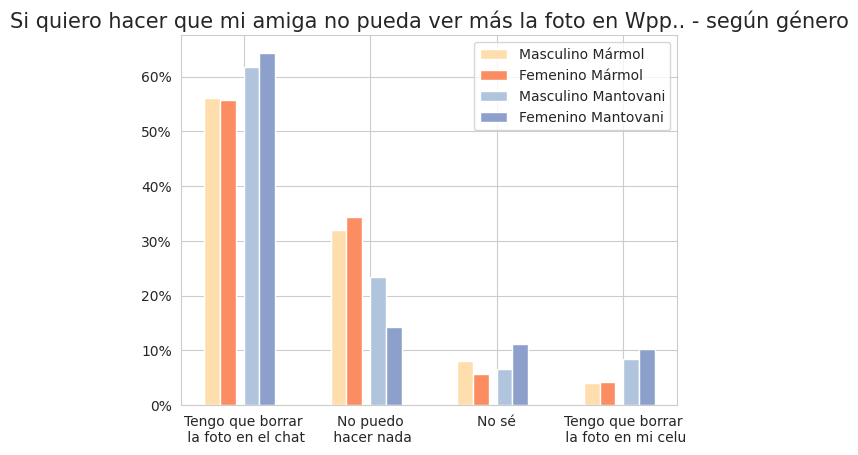

In [13]:
# Si quiero hacer que mi amiga no pueda ver más la foto, ¿qué puedo hacer? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["amiga_no_ver_foto"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Tengo que borrar la foto en el chat.": "Tengo que borrar\n la foto en el chat",
                              "No puedo hacer nada, mi amiga ahora también tiene la foto y no tengo manera de sacársela.": "No puedo\n hacer nada",
                              "Tengo que borrar la foto en la Galería de fotos de mi celular.": "Tengo que borrar\n la foto en mi celu"}).fillna(0)

result = result.reindex(["Tengo que borrar\n la foto en el chat",
          "No puedo\n hacer nada", 
          "No sé", 
          "Tengo que borrar\n la foto en mi celu"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si quiero hacer que mi amiga no pueda ver más la foto en Wpp.. - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('amiga_no_ver_foto_genero.png')

* No hay grandes diferencias en el Mármol
* En el mantovani las chicas eligen un 10% menos No puedo hacer nada

# ¿Cómo viaja un mensaje de Wpp sin Wi-Fi?

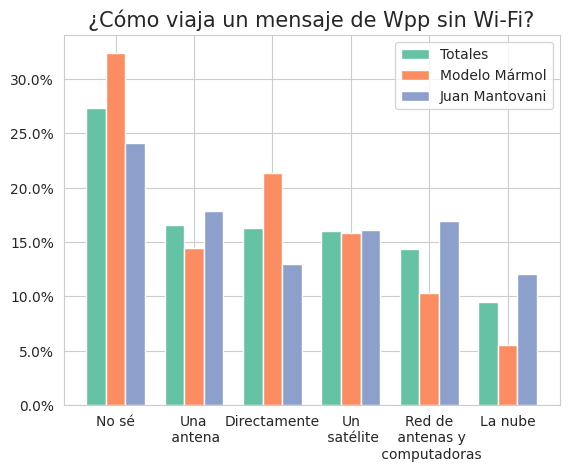

In [18]:
# ¿Cómo viaja un mensaje de Wpp sin Wi-Fi?
data_total = df_fe["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

result = result.reindex(["No sé", "Una\n antena", "Directamente", "Un\n satélite", "Red de\n antenas y\n computadoras", "La nube"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo viaja un mensaje de Wpp sin Wi-Fi?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('como_viaja_wpp.png')

* En Mármol se eligen un 15% más la opción No sey la opción Directamente.
* En Mantovani se eligen un 15% más la opción "Red de antenas y computadoras" y "la nube"

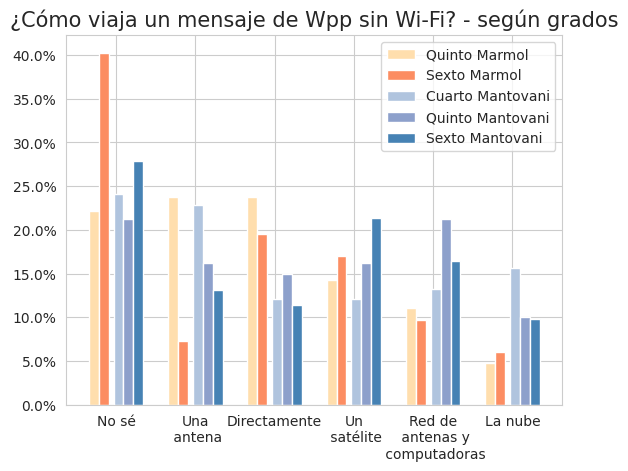

In [19]:
# ¿Cómo viaja un mensaje de Wpp sin Wi-Fi? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Marmol',
                                1:'Sexto Marmol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

result = result.reindex(["No sé", "Una\n antena", "Directamente", "Un\n satélite", "Red de\n antenas y\n computadoras", "La nube"])

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Marmol']    , width=bar_width, label = 'Quinto Marmol', color='navajowhite')
plt.bar(br2, result['Sexto Marmol']     , width=bar_width, label = 'Sexto Marmol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo viaja un mensaje de Wpp sin Wi-Fi? - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('como_viaja_wpp_grados.png')

* En el Mármol el 6to gradoelige un 20% más la opción "No sé" que 5to y un 20% menos la opción "una antena"
* En el Mantovani, de 4to a 6to, baja un 10% la respuesta "Una antena", sube un 10% "Un satélite" y sube la respuesta "Red de antenas y compus" un 10% en 5to y luego baja en 6to.

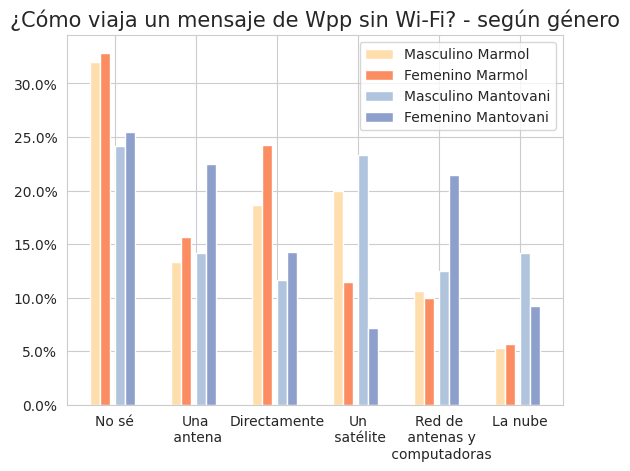

In [20]:
# ¿Cómo viaja un mensaje de Wpp sin Wi-Fi? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["como_viaja_wpp"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"El mensaje se manda a través de una antena.": "Una\n antena",
                              "El mensaje se manda directamente.": "Directamente",
                              "El mensaje se manda a través de un satélite.": "Un\n satélite",
                              "El mensaje se manda a través de una red de antenas y computadoras.": "Red de\n antenas y\n computadoras",
                              "El mensaje se manda a través de la nube.": "La nube"}).fillna(0)

result = result.reindex(["No sé", "Una\n antena", "Directamente", "Un\n satélite", "Red de\n antenas y\n computadoras", "La nube"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9 , 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"],     width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"],      width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo viaja un mensaje de Wpp sin Wi-Fi? - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('como_viaja_wpp_genero.png')

* En ambos colegios los chicos eligen arriba de un 10% más la opción "Un satélite".
* Marmol: Las chicas eligen un 5% más la opción directamente.
* Mantovani: Las chicas eligen un 5% más "Una antena". Los chicos eligen un 20% más un satélite. También las chicas eligen un 10% más la opción correcta, "Red de antenas y compus". Y los chicos un 5% más La nube.

# Si me llega un mensaje por WhatsApp con un link para descargar una aplicación, ¿cuál de las siguientes opciones creés que es la correcta?

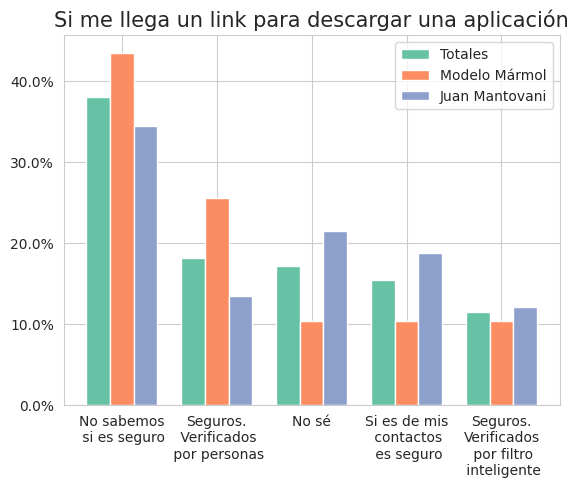

In [25]:
# Si me llega un mensaje por WhatsApp con un link para descargar una aplicación
data_total = df_fe["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

result = result.reindex(["No sabemos\n si es seguro", "Seguros.\n Verificados\n por personas", "No sé", "Si es de mis\n contactos\n es seguro", "Seguros.\nVerificados\n por filtro\n inteligente"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si me llega un link para descargar una aplicación", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('link_descarga.png')

* Mármol elige un 10% más "No sabemos si es seguro" y "verificados por personas"
* Mantovani elige 10% más "No se" y "Si es de mis contactos es seguro". 

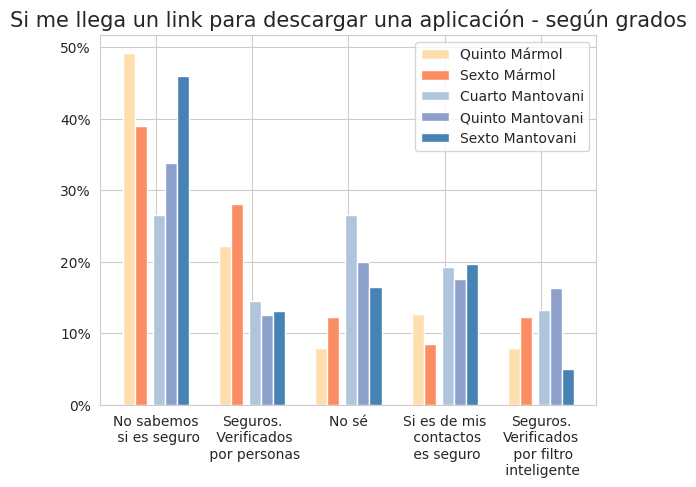

In [26]:
# Si me llega un link para descargar una aplicación - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

result = result.reindex(["No sabemos\n si es seguro", "Seguros.\n Verificados\n por personas", "No sé", "Si es de mis\n contactos\n es seguro", "Seguros.\nVerificados\n por filtro\n inteligente"])

br1 = [1, 3, 5, 7, 9]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si me llega un link para descargar una aplicación - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('link_descarga_grados.png')

* Modelo Mármol: 6to elige un 10% menos "No sabemos si es seguro" y un 5% más "Verificados por personas"
* Mantovani: De 4to a 6to sube un 20% "No sabemos si es seguro", baja un 10% la opción "No sé" y un 10% "Verificados por filtro inteligente"

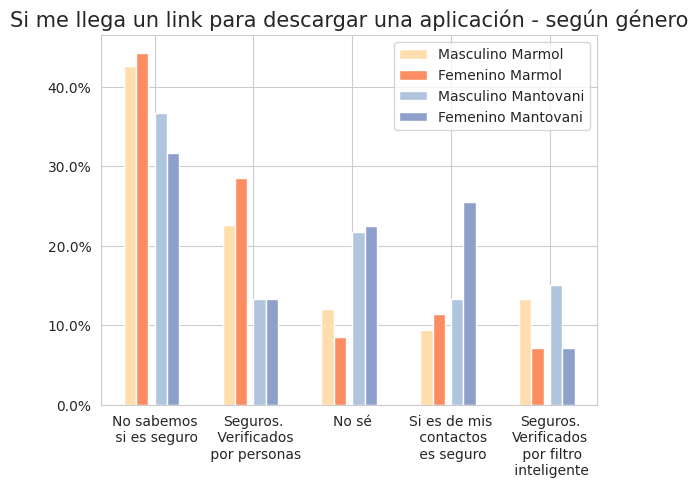

In [27]:
# Si me llega un link para descargar una aplicación - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["link_descarga"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Marmol", 1: "Femenino Marmol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Los mensajes recibidos no están verificados de ninguna forma. No podemos saber si el link es seguro.": "No sabemos\n si es seguro",
                              "Los mensajes recibidos están verificados por personas en WhatsApp. El link es seguro.": "Seguros.\n Verificados\n por personas",
                              "No sé.": "No sé",
                              "Si el mensaje fue enviado por uno de mis contactos entonces el link es seguro.": "Si es de mis\n contactos\n es seguro",
                              "Los mensajes recibidos están verificados por un filtro inteligente. El link es seguro.": "Seguros.\nVerificados\n por filtro\n inteligente"}).fillna(0)

result = result.reindex(["No sabemos\n si es seguro", "Seguros.\n Verificados\n por personas", "No sé", "Si es de mis\n contactos\n es seguro", "Seguros.\nVerificados\n por filtro\n inteligente"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Marmol"],     width=bar_width, label = 'Masculino Marmol', color='navajowhite')
plt.bar(br2,result["Femenino Marmol"],      width=bar_width, label = 'Femenino Marmol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Si me llega un link para descargar una aplicación - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('link_descarga_genero.png')

* No hay muchas diferencias en el Mármol, las chicas eligen un 5% más la opción "Verificados por personas", y los varones un 5% más "Verificados por filtro inteligente"
* En el Mantovani las chicas eligen un 15% más "Si es de mis contactos es seguro" y los varones un 5% más "Verificados por filtro inteligente"

## En informática, ¿qué es la nube?

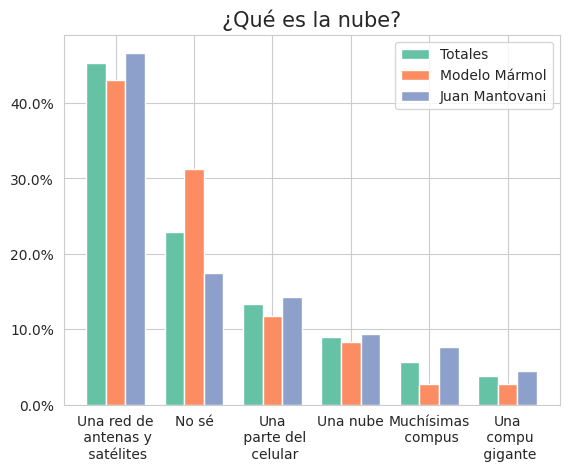

In [12]:
# En informática, ¿qué es la nube?
data_total = df_fe["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Qué es la nube?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('que_es_nube.png')

* En el mármol se elige un 10% más la opción No se.

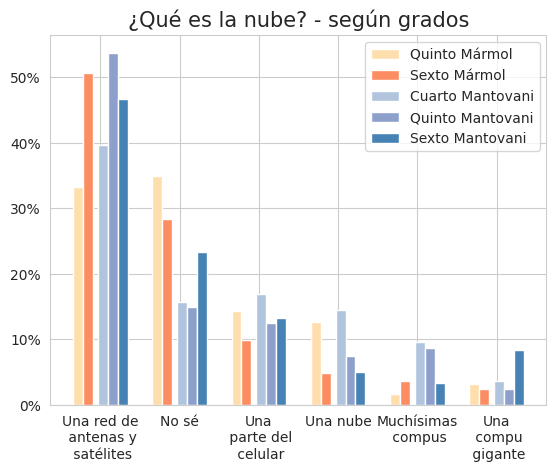

In [16]:
# En informática, ¿qué es la nube? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(     columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                            index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

result = result.reindex(["Una red de\n antenas y\n satélites",
                         "No sé",
                         "Una\n parte del\n celular",
                         "Una nube",
                         "Muchísimas\n compus",
                         "Una\n compu\n gigante"
                         ])

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Qué es la nube? - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('que_es_nube_grados.png')

* Mármol, 6to elige un 15% más "Red de antenas...", Eligen un 5% menos "Una nube" 
* Mantovani, de 4to a 6to hay un aumento de un 5% en "Red de antenas..." y "No se". Se elige un 10% menos "Una nube"

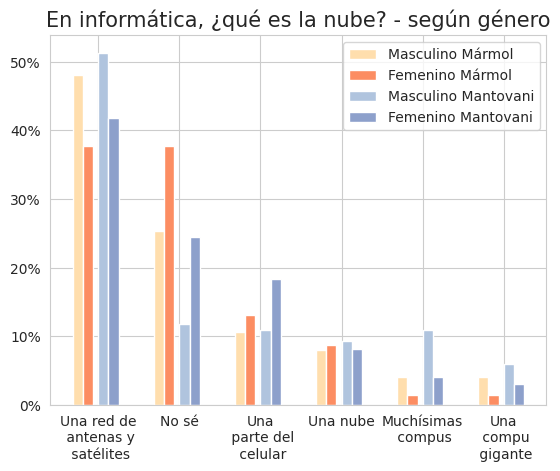

In [78]:
# En informática, ¿qué es la nube? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["que_es_nube"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Una red de antenas y satélites": "Una red de\n antenas y\n satélites",
                              "No sé": "No sé",
                              "Una parte del celular": "Una\n parte del\n celular",
                              "Muchísimas computadoras (tantas que podrían llenar una cancha de fútbol)": "Muchísimas\n compus",
                              "Una computadora gigante":"Una\n compu\n gigante"}).fillna(0)

result = result.reindex(["Una red de\n antenas y\n satélites",
                         "No sé",
                         "Una\n parte del\n celular",
                         "Una nube",
                         "Muchísimas\n compus",
                         "Una\n compu\n gigante"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("En informática, ¿qué es la nube? - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('que_es_nube_genero.png')

* Las respuestas analizadas en base al género del Modelo Mármol y Juan Mantovani son iguales:
* Las chicas eligen un 10% menos "Una red...", las chicas eligen un 10% más "No se" y un 5% más "Una parte del celular".
* Los varones del Mantovani eligen un 5% más "Muchisimas compus"

# Afirmaciones sobre la nube

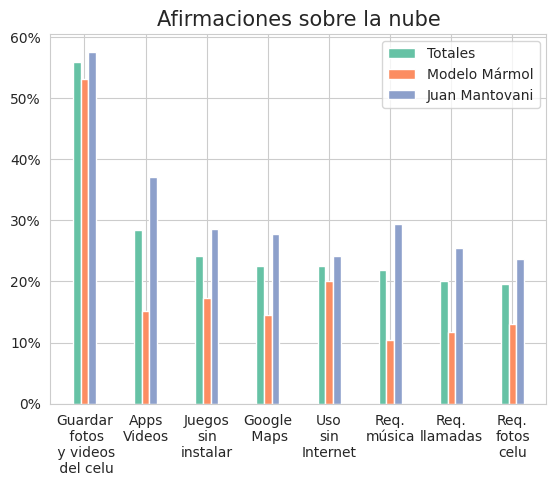

In [51]:
# Afirmaciones sobre la nube
data_total = df_fe["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)
data_marmol = marmol["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol).sort_values(ascending=False)
data_mantovani = mantovani["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1)
result = result.rename( columns={ 0:'Totales',
                                  1:'Modelo Mármol',
                                  2:'Juan Mantovani'},
                        index= {"Lanubemepermiteguardarlasfotosyvideosdelcelular": "Guardar\n fotos\n y videos\n del celu",
                                "InstagramyTikTokusanlanubeparacompartirsusvideos": "Apps\nVideos",
                                "Sepuedeusarlanubeparajugarjuegossininstalarlos": "Juegos\nsin\ninstalar",
                                "GoogleMapsdescargasusmapasdelanube": "Google\n Maps",
                                "PodemosutilizarlanubesinconexiónaInternet": "Uso\nsin\nInternet",
                                "Sinlanubeseríaimposibleescucharmúsicaenelcelular": "Req.\nmúsica",
                                "Sinlanubenoseríaposiblehacerllamadasporcelular": "Req.\nllamadas",
                                "Sinlanubeseríaimposiblesacarfotosconelcelular": "Req.\nfotos\ncelu"
                                }).fillna(0)

result = result.reindex(["Guardar\n fotos\n y videos\n del celu","Apps\nVideos","Juegos\nsin\ninstalar","Google\n Maps","Uso\nsin\nInternet","Req.\nmúsica","Req.\nllamadas","Req.\nfotos\ncelu"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11, 13, 15]
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales']       , width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'] , width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Afirmaciones sobre la nube", fontsize=15)
plt.xticks([r + bar_width for r in br1], result.index)
plt.legend()
plt.savefig('afirmaciones_nube.png')

* En esta pregunta se permiten varias respuestas
* El Mantovani elige un 20% más las respuestas "Las apps las usan para compartir sus videos" y "Sin la nube no se podría escuchar música en el celular". Tambien eligen un 10% más "Permite jugar juegos sin instalarlos", "Google maps la utiliza para sus videos", "Es requerida para realizar llamadas" y "Es requerida para sacar fotos con el celular"

In [7]:
# Promedio en cantidad de respuestas - Afirmaciones sobre la nube
data_total = df_fe["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol = marmol["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani = mantovani["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_total,data_marmol,data_mantovani]
labels = ['Totales','Modelo Marmol','Juan Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Afirmaciones sobre la nube")
result.head()

Promedio en cantidad de respuestas - Afirmaciones sobre la nube


,Totales,Modelo Marmol,Juan Mantovani
0,2.149051,1.551724,2.535714


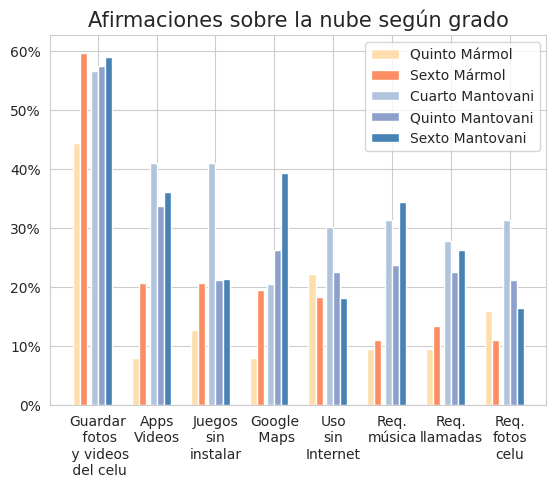

In [9]:
# Afirmaciones sobre la nube según grado
data_total = df_fe["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_total).sort_values(ascending=False)

data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_quinto).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_sexto).sort_values(ascending=False)

data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_cuarto).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_quinto).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_sexto).sort_values(ascending=False)

dfs = [data_marmol_quinto, data_marmol_sexto, data_mantovani_cuarto, data_mantovani_quinto, data_mantovani_sexto]

result = pd.concat(dfs, axis=1)
result = result.rename( columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                        index= {"Lanubemepermiteguardarlasfotosyvideosdelcelular": "Guardar\n fotos\n y videos\n del celu",
                                "InstagramyTikTokusanlanubeparacompartirsusvideos": "Apps\nVideos",
                                "Sepuedeusarlanubeparajugarjuegossininstalarlos": "Juegos\nsin\ninstalar",
                                "GoogleMapsdescargasusmapasdelanube": "Google\n Maps",
                                "PodemosutilizarlanubesinconexiónaInternet": "Uso\nsin\nInternet",
                                "Sinlanubeseríaimposibleescucharmúsicaenelcelular": "Req.\nmúsica",
                                "Sinlanubenoseríaposiblehacerllamadasporcelular": "Req.\nllamadas",
                                "Sinlanubeseríaimposiblesacarfotosconelcelular": "Req.\nfotos\ncelu"
                                }).fillna(0)

result = result.reindex(["Guardar\n fotos\n y videos\n del celu","Apps\nVideos","Juegos\nsin\ninstalar","Google\n Maps","Uso\nsin\nInternet","Req.\nmúsica","Req.\nllamadas","Req.\nfotos\ncelu"])

bar_width = 0.12

ticks = np.arange(len(result))

br_marmol_quinto = ticks
br_marmol_sexto = [x + bar_width for x in br_marmol_quinto]

br_mantovani_cuarto = [x + 1.5* bar_width for x in br_marmol_sexto]
br_mantovani_quinto = [x + bar_width for x in br_mantovani_cuarto]
br_mantovani_sexto  = [x + bar_width for x in br_mantovani_quinto]

plt.bar(br_marmol_quinto,    result['Quinto Mármol'], width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br_marmol_sexto,     result['Sexto Mármol'], width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br_mantovani_cuarto, result['Cuarto Mantovani'], width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br_mantovani_quinto, result['Quinto Mantovani'], width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br_mantovani_sexto,  result['Sexto Mantovani'], width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Afirmaciones sobre la nube según grado", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, result.index)
plt.legend()

plt.savefig('afirmaciones_nube_grado.png')

* En esta pregunta se permiten varias respuestas
* Mármol: "Guardar fotos y videos..." es elegida un 15% más en 6to. "Las apps las usan para compartir..." es elegida un 10% más junto con "Google maps"
* Mantovani: Curiosamente, la opción de "Juegos sin instalar" es elegida un 20% menos en 5to y 6to. "Google maps", un 20% más en 6to y finalmente "Uso sin internet" y "Requerida para sacar fotos con el celu" bajan un 10% y 15% respectivamente. 

In [12]:
# Promedio en cantidad de respuestas - Afirmaciones sobre la nube según grado
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]
labels = ['Quinto Marmol','Sexto Marmol','Cuarto Mantovani','Quinto Mantovani','Sexto Mantovani']

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Afirmaciones sobre la nube según grado")
result.head()

Promedio en cantidad de respuestas - Afirmaciones sobre la nube según grado


,Quinto Marmol,Sexto Marmol,Cuarto Mantovani,Quinto Mantovani,Sexto Mantovani
0,1.301587,1.743902,2.795181,2.2875,2.508197


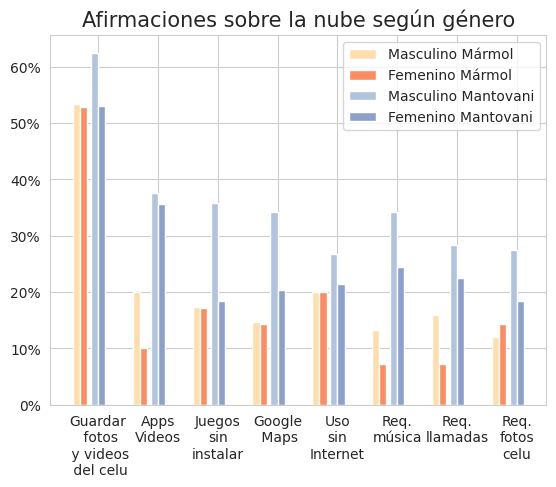

In [13]:
# Afirmaciones sobre la nube
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_masc).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_marmol_fem).sort_values(ascending=False)

data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_masc).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').sum().div(cant_mantovani_fem).sort_values(ascending=False)

dfs = [data_marmol_mas, data_marmol_fem, data_mantovani_mas, data_mantovani_fem]

result = pd.concat(dfs, axis=1)
result = result.rename( columns={0: "Masculino Mármol",
                                1: "Femenino Mármol",
                                2: "Masculino Mantovani",
                                3: "Femenino Mantovani"},
                        index= {"Lanubemepermiteguardarlasfotosyvideosdelcelular": "Guardar\n fotos\n y videos\n del celu",
                                "InstagramyTikTokusanlanubeparacompartirsusvideos": "Apps\nVideos",
                                "Sepuedeusarlanubeparajugarjuegossininstalarlos": "Juegos\nsin\ninstalar",
                                "GoogleMapsdescargasusmapasdelanube": "Google\n Maps",
                                "PodemosutilizarlanubesinconexiónaInternet": "Uso\nsin\nInternet",
                                "Sinlanubeseríaimposibleescucharmúsicaenelcelular": "Req.\nmúsica",
                                "Sinlanubenoseríaposiblehacerllamadasporcelular": "Req.\nllamadas",
                                "Sinlanubeseríaimposiblesacarfotosconelcelular": "Req.\nfotos\ncelu"
                                }).fillna(0)

result = result.reindex(["Guardar\n fotos\n y videos\n del celu","Apps\nVideos","Juegos\nsin\ninstalar","Google\n Maps","Uso\nsin\nInternet","Req.\nmúsica","Req.\nllamadas","Req.\nfotos\ncelu"])

bar_width = 0.12

ticks = np.arange(len(result))

b1 = ticks
b2 = [x + bar_width for x in b1]
b3 = [x + 1.5* bar_width for x in b2]
b4 = [x + bar_width for x in b3]

plt.bar(b1,result["Masculino Mármol"]   , width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(b2,result["Femenino Mármol"]    , width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(b3,result["Masculino Mantovani"], width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(b4,result["Femenino Mantovani"] , width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Afirmaciones sobre la nube según género", fontsize=15)
ticks = [x + 3*bar_width for x in ticks]
plt.xticks(ticks, result.index)
plt.legend()

plt.savefig('afirmaciones_nube_genero.png')

* En esta pregunta se permiten varias respuestas
* Mármol: las chicas eligen un 10% menos la opción "las apps la usan para compartir sus videos".
* Mantovani: Las chicas eligen un 10% menos la opcion "guardar fotos y videos del celu". También eligen un 15% menos "jugar juegos sin isntalar" y "Maps la usa para sus mapas". El resto de las respuestas también tienen un menor porcentaje de elección en las mujeres.

In [14]:
# Promedio en cantidad de respuestas - Afirmaciones sobre la nube según género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["afirmaciones_nube"].str.replace(" ", "").str.get_dummies(sep=',').transpose().sum().mean()

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]
labels = ["Masculino Marmol","Femenino Marmol","Masculino Mantovani","Femenino Mantovani"]

result = pd.DataFrame(data=[dfs], columns=labels)
print("Promedio en cantidad de respuestas - Afirmaciones sobre la nube según género")
result.head()

Promedio en cantidad de respuestas - Afirmaciones sobre la nube según género


,Masculino Marmol,Femenino Marmol,Masculino Mantovani,Femenino Mantovani
0,1.666667,1.428571,2.866667,2.142857


# Cómo se comportan Internet y la nube

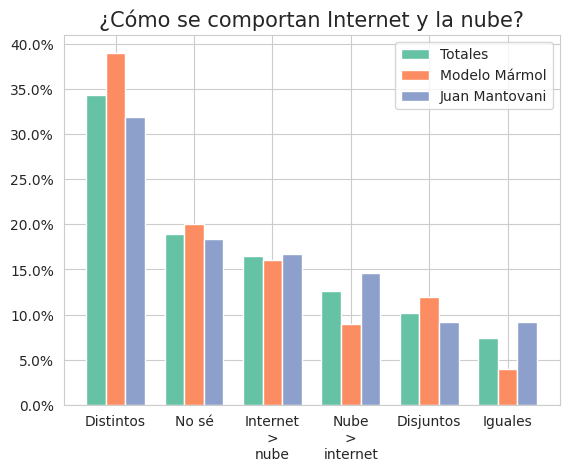

In [74]:
# Cómo se comportan Internet y la nube
data_total = df_fe["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)

result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Internet y la nube tienen algunas funciones comunes y algunas funciones distintas.": "Distintos",
                              "No sé.": "No sé",
                              "Con Internet podemos hacer más cosas que con la nube.": "Internet\n>\nnube",
                              "Con la nube podemos hacer más cosas que con Internet.": "Nube\n>\ninternet",
                              "Internet y la nube no tienen funciones en común.":"Disjuntos",
                              "Podemos hacer exactamente lo mismo con Internet que con la nube.": "Iguales"}).fillna(0)

result = result.reindex(["Distintos", "No sé","Internet\n>\nnube","Nube\n>\ninternet","Disjuntos","Iguales"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo se comportan Internet y la nube?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('como_se_comportan.png')

* No hay diferencias mayores a 5% en las respuestas de ambos colegios

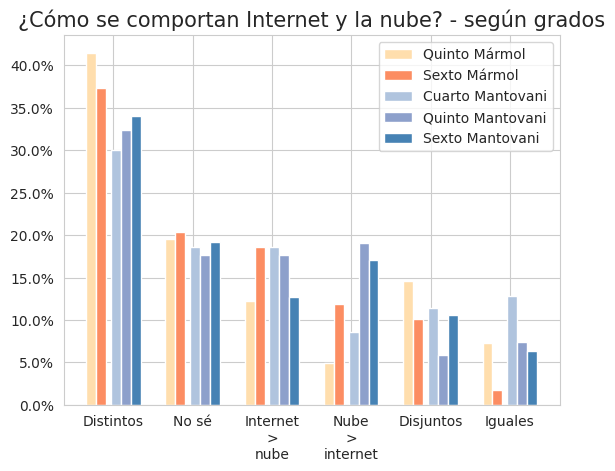

In [75]:
# Cómo se comportan Internet y la nube - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(     columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Internet y la nube tienen algunas funciones comunes y algunas funciones distintas.": "Distintos",
                              "No sé.": "No sé",
                              "Con Internet podemos hacer más cosas que con la nube.": "Internet\n>\nnube",
                              "Con la nube podemos hacer más cosas que con Internet.": "Nube\n>\ninternet",
                              "Internet y la nube no tienen funciones en común.":"Disjuntos",
                              "Podemos hacer exactamente lo mismo con Internet que con la nube.": "Iguales"}).fillna(0)

result = result.reindex(["Distintos", "No sé","Internet\n>\nnube","Nube\n>\ninternet","Disjuntos","Iguales"])

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo se comportan Internet y la nube? - según grados", fontsize=15)
plt.xticks([x + 2.25*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('como_se_comportan_grados.png')

* La única diferencia notoria entre grados es entre 4to y 6to del Mantovani, eligiendo que la funcionalidad de la nube es mayor a la del internet un 10% más en 6to.

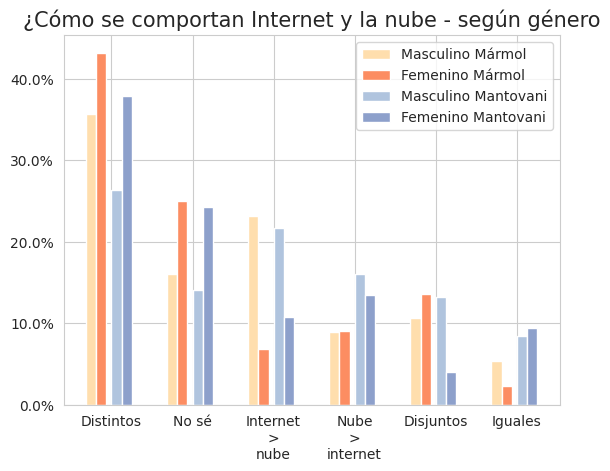

In [77]:
# Cómo se comportan Internet y la nube - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["como_se_comportan"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Internet y la nube tienen algunas funciones comunes y algunas funciones distintas.": "Distintos",
                              "No sé.": "No sé",
                              "Con Internet podemos hacer más cosas que con la nube.": "Internet\n>\nnube",
                              "Con la nube podemos hacer más cosas que con Internet.": "Nube\n>\ninternet",
                              "Internet y la nube no tienen funciones en común.":"Disjuntos",
                              "Podemos hacer exactamente lo mismo con Internet que con la nube.": "Iguales"}).fillna(0)

result = result.reindex(["Distintos", "No sé","Internet\n>\nnube","Nube\n>\ninternet","Disjuntos","Iguales"])

bar_width = 0.25

br1 = [1, 3, 5, 7, 9, 11]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Cómo se comportan Internet y la nube - según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('como_se_comportan_genero.png')

* Los chicos del modelo eligen un 15% más "Internet > nube".
* Las chicas del mantovani eligen un 10% más "Distintos" y "No se". Mientras que los chicos, como en el modelo mármol, eligen un 10% más "Internet > nube".

# ¿Conocés o alguna vez usaste Wikipedia?

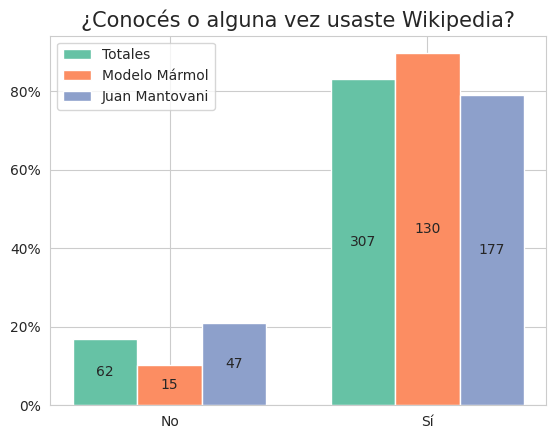

In [82]:
# # ¿Conocés o alguna vez usaste Wikipedia?
dfs = [df["uso_wikipedia"].value_counts() for df in [df_fe, marmol, mantovani]]
result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 
                                1: "Modelo Mármol", 
                                2: "Juan Mantovani"}
                                ).fillna(0).astype('Int64').sort_index()

cantidades = [ result["Totales"].to_numpy(),
               result["Modelo Mármol"].to_numpy(), 
               result["Juan Mantovani"].to_numpy()]

bar_width = 0.25
br1 = np.arange(len(result["Totales"]))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

fig, ax = plt.subplots()

plt.bar(br1,result["Totales"].div(cant_total)           , width=bar_width, label = 'Totales')
plt.bar(br2,result["Modelo Mármol"].div(cant_marmol)    , width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result["Juan Mantovani"].div(cant_mantovani), width=bar_width, label = 'Juan Mantovani')

i = 0
for bars in ax.containers:
    ax.bar_label(bars, labels=cantidades[i], label_type="center")
    i=i+1

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Conocés o alguna vez usaste Wikipedia?", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()

plt.savefig('uso_wikipedia.png')

* No hay grandes diferencias en porcentajes. Notemos que perderemos un 20% de los alumnos del Mantovani en la siguiente pregunta y un 10% del Modelo Mármol respectivamente.

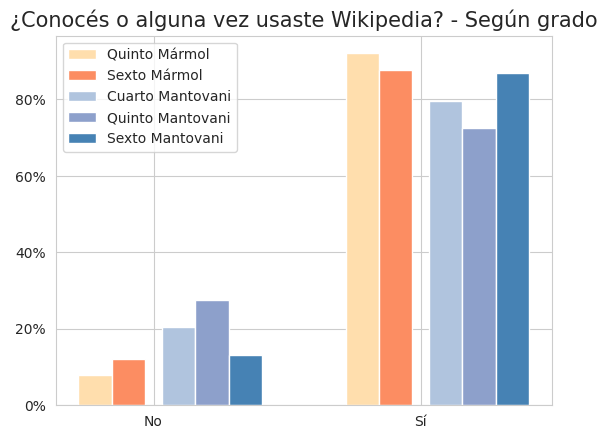

In [15]:
# ¿Conocés o alguna vez usaste Wikipedia? - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'})

result = result.reindex(["No","Sí"])

bar_width = 0.25

br1 = [1, 3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Conocés o alguna vez usaste Wikipedia? - Según grado", fontsize=15)
plt.xticks([x + 1.75*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('uso_wikipedia_grados.png')


* El porcentaje de alumnos de 5to en el modelo es un 10% y un 15% en 6to
* Los alumnos del mantovani se reducen en un 20% en 4to, casi 30% en 5to y 15% en sexto

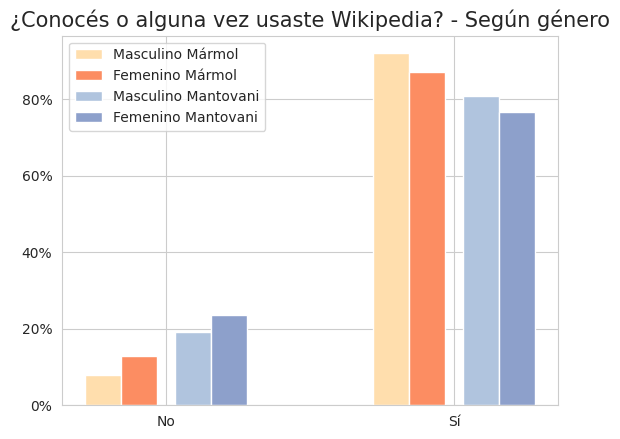

In [16]:
# ¿Conocés o alguna vez usaste Wikipedia? - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["uso_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"})

result = result.reindex(["No","Sí"])

bar_width = 0.25

br1 = [1, 3]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("¿Conocés o alguna vez usaste Wikipedia? - Según género", fontsize=15)
plt.xticks([x + 1.75*bar_width for x in br1], result.index)
plt.legend()
plt.savefig('uso_wikipedia_genero.png')


* No hay grandes diferencias por genero. En Marmol están centrados en 10% y en el Mantovani en 20%

# Sobre los artículos de Wikipedia

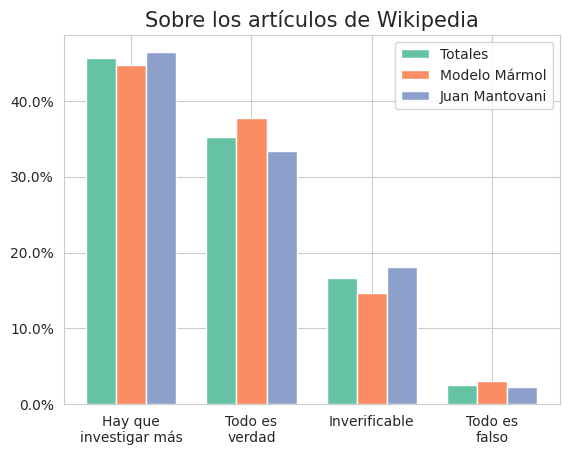

In [104]:
# Sobre los artículos de Wikipedia
data_total = df_fe["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol = marmol["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani = mantovani["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_total, data_marmol, data_mantovani]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Totales", 1: "Modelo Mármol", 2: "Juan Mantovani"},
                       index={"Hace falta investigar más para decidir si la información es verdadera o falsa.": "Hay que\ninvestigar más",
                              "Toda la información en el artículo es verdadera porque está verificada.": "Todo es\nverdad",
                              "No hay forma de saber si la información del artículo es verdadera o falsa.": "Inverificable",
                              "Todo lo que está en el artículo es falso: cualquier usuario pudo haberlo inventado.": "Todo es\nfalso"}).fillna(0)

result = result.reindex(["Hay que\ninvestigar más","Todo es\nverdad","Inverificable","Todo es\nfalso"])

bar_width = 0.25

br1 = np.arange(len(data_total))
br2 = [x + bar_width for x in br1]
br3 = [x + bar_width for x in br2]

plt.bar(br1,result['Totales'],        width=bar_width, label = 'Totales')
plt.bar(br2,result['Modelo Mármol'],  width=bar_width, label = 'Modelo Mármol')
plt.bar(br3,result['Juan Mantovani'], width=bar_width, label = 'Juan Mantovani')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Sobre los artículos de Wikipedia", fontsize=15)
plt.xticks([x + bar_width for x in br1], result.index)
plt.legend()
plt.savefig('sobre_wikipedia.png')

* No hay diferencias entre colegios para esta respuesta

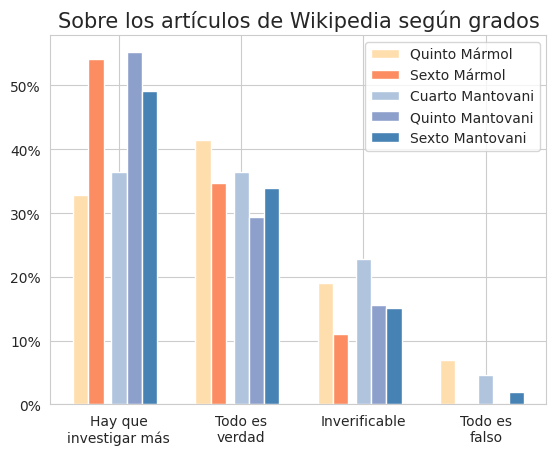

In [108]:
# Sobre los artículos de Wikipedia - Grados
data_marmol_quinto = marmol[marmol['grado']=="Quinto"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_sexto = marmol[marmol['grado']=="Sexto"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_cuarto = mantovani[mantovani['grado']=="Cuarto"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_quinto = mantovani[mantovani['grado']=="Quinto"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_sexto = mantovani[mantovani['grado']=="Sexto"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_quinto,data_marmol_sexto,data_mantovani_cuarto,data_mantovani_quinto,data_mantovani_sexto]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0:'Quinto Mármol',
                                1:'Sexto Mármol',
                                2:'Cuarto Mantovani',
                                3:'Quinto Mantovani',
                                4:'Sexto Mantovani'},
                       index={"Hace falta investigar más para decidir si la información es verdadera o falsa.": "Hay que\ninvestigar más",
                              "Toda la información en el artículo es verdadera porque está verificada.": "Todo es\nverdad",
                              "No hay forma de saber si la información del artículo es verdadera o falsa.": "Inverificable",
                              "Todo lo que está en el artículo es falso: cualquier usuario pudo haberlo inventado.": "Todo es\nfalso"}).fillna(0)

result = result.reindex(["Hay que\ninvestigar más","Todo es\nverdad","Inverificable","Todo es\nfalso"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]
br5 = [x +     bar_width for x in br4]

plt.bar(br1, result['Quinto Mármol']    , width=bar_width, label = 'Quinto Mármol', color='navajowhite')
plt.bar(br2, result['Sexto Mármol']     , width=bar_width, label = 'Sexto Mármol', color='C1')
plt.bar(br3, result['Cuarto Mantovani'] , width=bar_width, label = 'Cuarto Mantovani', color='lightsteelblue')
plt.bar(br4, result['Quinto Mantovani'] , width=bar_width, label = 'Quinto Mantovani', color='C2')
plt.bar(br5, result['Sexto Mantovani']  , width=bar_width, label = 'Sexto Mantovani', color='steelblue')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Sobre los artículos de Wikipedia según grados", fontsize=15)
plt.xticks([x + 2.5*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('sobre_wikipedia_grados.png')


* En el modelo mármol, los alumnos de 6to eligen un 20% más la opción "Hay que investigar más" y cerca de un 10% menos "Inverificable"
* En el mantovani se elige un 15% más "Hay que investigar más" a medida que avanzan de curso.

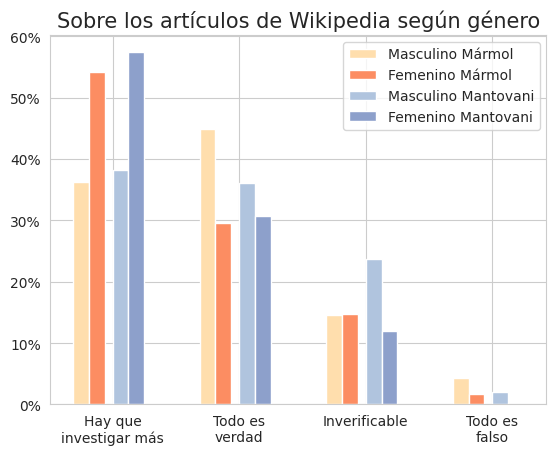

In [111]:
# Sobre los artículos de Wikipedia - Género
data_marmol_mas = marmol[marmol['genero']=="Masculino"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_marmol_fem = marmol[marmol['genero']=="Femenino"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_mas = mantovani[mantovani['genero']=="Masculino"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)
data_mantovani_fem = mantovani[mantovani['genero']=="Femenino"]["sobre_wikipedia"].value_counts(normalize=True).sort_values(ascending=False)

dfs = [data_marmol_mas,data_marmol_fem,data_mantovani_mas,data_mantovani_fem]

result = pd.concat(dfs, axis=1, ignore_index=True)
result = result.rename(columns={0: "Masculino Mármol", 1: "Femenino Mármol", 2: "Masculino Mantovani", 3: "Femenino Mantovani"},
                       index={"Hace falta investigar más para decidir si la información es verdadera o falsa.": "Hay que\ninvestigar más",
                              "Toda la información en el artículo es verdadera porque está verificada.": "Todo es\nverdad",
                              "No hay forma de saber si la información del artículo es verdadera o falsa.": "Inverificable",
                              "Todo lo que está en el artículo es falso: cualquier usuario pudo haberlo inventado.": "Todo es\nfalso"}).fillna(0)

result = result.reindex(["Hay que\ninvestigar más","Todo es\nverdad","Inverificable","Todo es\nfalso"])

bar_width = 0.25

br1 = [1, 3, 5, 7]
br2 = [x +     bar_width for x in br1]
br3 = [x + 1.5*bar_width for x in br2]
br4 = [x +     bar_width for x in br3]

plt.bar(br1,result["Masculino Mármol"],     width=bar_width, label = 'Masculino Mármol', color='navajowhite')
plt.bar(br2,result["Femenino Mármol"],      width=bar_width, label = 'Femenino Mármol', color='C1')
plt.bar(br3,result["Masculino Mantovani"],  width=bar_width, label = 'Masculino Mantovani', color='lightsteelblue')
plt.bar(br4,result["Femenino Mantovani"],   width=bar_width, label = 'Femenino Mantovani', color='C2')

plt.gca().yaxis.set_major_formatter(PercentFormatter(1))
plt.title("Sobre los artículos de Wikipedia según género", fontsize=15)
plt.xticks([x + 2*bar_width for x in br1], result.index)
plt.legend(loc='upper right')
plt.savefig('sobre_wikipedia_genero.png')

* Las chicas en el Mármol eligen un 15% más "Hay que investigar más" y un 15% menos "Todo es verdad"
* Las chicas del Mantovani eligen casi un 20% más "Hay que investigar más" y un 10% menos "Inverificable"
* El comportamiento de las chicas para "Hay que investigar más" se repite en ambos colegios.